In [43]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [44]:
ROOT = Path.cwd()

EXP = ROOT / "results" / "experiments"

AT_ADM = EXP / "icd_codes"

UPTO_ADM = EXP / "icd_codes_upto"

In [45]:
all_dfs = []

# Iterate over subfolders
for folder in EXP.iterdir():
    for subfolder in folder.iterdir():
        if subfolder.is_dir():
            csv_file = subfolder / "summary_metrics.csv"
            
            if csv_file.exists():
                df = pd.read_csv(csv_file)
                
                # Add folder name as new column
                df["folder_name"] = subfolder.name
                df["adm_type"] = folder.name
                
                all_dfs.append(df)

# Concatenate all dataframes
if all_dfs:
    concat_df = pd.concat(all_dfs, ignore_index=True)
else:
    concat_df = pd.DataFrame()

In [46]:
concat_df["cohort_name"] = np.where(concat_df["folder_name"].str.contains("aplasia", case=False, na=False), "aplasia", "neutropenic fever")

concat_df.loc[concat_df["Feature_Type"].isna() & concat_df["folder_name"].str.contains("node2vec"),"Feature_Type"] = "Node2Vec"
concat_df.loc[concat_df["Feature_Type"].isna() & concat_df["folder_name"].str.contains("kane"),"Feature_Type"] = "Kane"
concat_df.loc[concat_df["Feature_Type"].isna() & concat_df["folder_name"].str.contains("clinvec", case=False), "Feature_Type"] = "ClinVec"

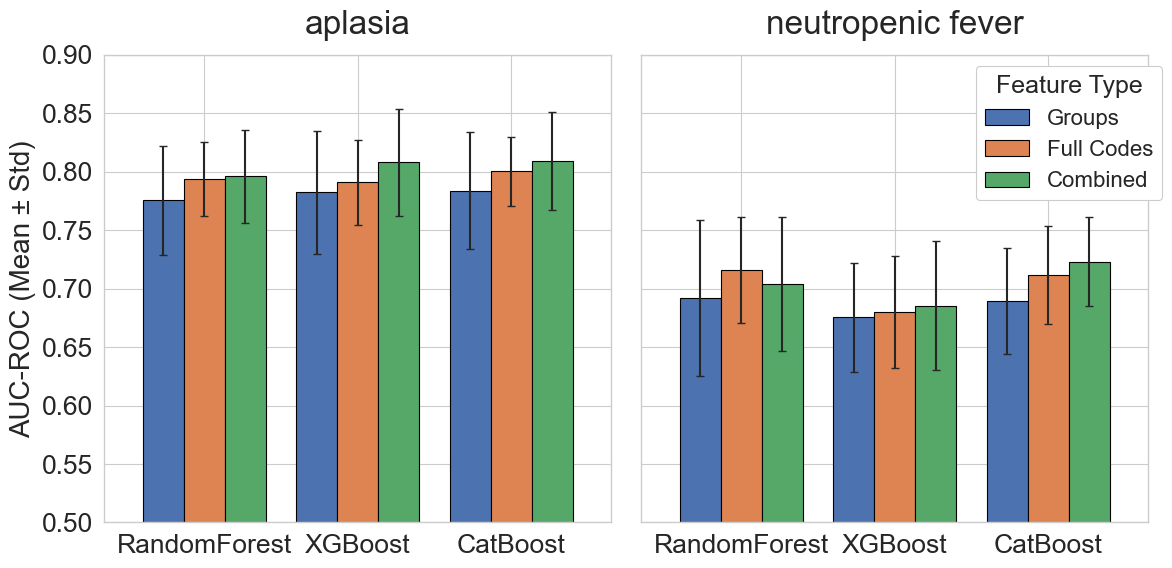

In [81]:
# FIGURE 1 - FULL CODES vs GROUPS vs COMBINED

sub_df = concat_df[concat_df["folder_name"].str.contains("OHE") & (concat_df["adm_type"]=="icd_codes")]

feature_order = ["Groups", "Full Codes", "Combined"]
model_order = ['RandomForest', 'XGBoost', 'CatBoost']
cohort_order = sub_df["cohort_name"].unique()

sns.set_theme(style="whitegrid", context="paper", font_scale=1.8)
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for i, (ax, cohort) in enumerate(zip(axes, cohort_order)):
    
    cohort_df = sub_df[sub_df["cohort_name"] == cohort]
    
    # Pivot Data
    p_mean = cohort_df.pivot(index="Model", columns="Feature_Type", values="Test_AUC_Mean")
    p_std = cohort_df.pivot(index="Model", columns="Feature_Type", values="Test_AUC_Std")
    
    # Reindex
    p_mean = p_mean.reindex(index=model_order, columns=feature_order)
    p_std = p_std.reindex(index=model_order, columns=feature_order)

    # PLOT
    p_mean.plot(
        kind="bar",
        yerr=p_std,
        ax=ax,
        capsize=3,
        width=0.8,
        edgecolor="black",
        linewidth=0.8,
        rot=0,
        error_kw={"elinewidth": 1.5}
    )
    
    #ax.set_title(cohort)
    ax.set_title(cohort, fontsize=24, pad=15)
    ax.set_xlabel("", fontsize=20) 
    ax.set_ylabel("AUC-ROC (Mean ± Std)" if i==0 else "", fontsize=20) 
    ax.tick_params(axis='both', which='major', labelsize=19)
    ax.set_ylim(0.5, 0.9)

    # Clean Legend
    if i == 0:
        ax.get_legend().remove()
    else:
        ax.legend(title="Feature Type",fontsize=16, title_fontsize=18, frameon=True, fancybox=True, framealpha=1, bbox_to_anchor=(1.05, 1))
       
os.makedirs("figures", exist_ok=True)
plt.tight_layout()
plt.savefig("figures/fig1.png", dpi=600)

In [92]:
# FIGURE 2 

sub_df = concat_df[(concat_df["adm_type"]=="icd_codes") & concat_df["Feature_Type"].isin(['Kane', 'Word2Vec', 'Node2Vec','ClinVec'])].copy()

model_order = ["RandomForest", "XGBoost", "CatBoost", "MLP_1Layer", "MLP_2Layer", "MLP_3Layer"]

sub_df["Model"] = pd.Categorical(sub_df["Model"], categories=model_order, ordered=True)

sub_df = sub_df.sort_values(["Model", "Dimension"])

In [93]:
sub_df.groupby(["Dimension", "Model"], observed=False)["Test_AUC_Mean"].mean()#.sort_values()

Dimension  Model       
10.0       RandomForest    0.607949
           XGBoost         0.597286
           CatBoost        0.614525
           MLP_1Layer      0.646555
           MLP_2Layer      0.636922
           MLP_3Layer      0.634835
50.0       RandomForest    0.645083
           XGBoost         0.637895
           CatBoost        0.650841
           MLP_1Layer      0.699798
           MLP_2Layer      0.699091
           MLP_3Layer      0.700979
100.0      RandomForest    0.657982
           XGBoost         0.657096
           CatBoost        0.661149
           MLP_1Layer      0.694085
           MLP_2Layer      0.699793
           MLP_3Layer      0.700594
128.0      RandomForest    0.635071
           XGBoost         0.621667
           CatBoost        0.618954
           MLP_1Layer      0.626688
           MLP_2Layer      0.612366
           MLP_3Layer      0.623243
1000.0     RandomForest    0.664782
           XGBoost         0.666752
           CatBoost        0.664641
    

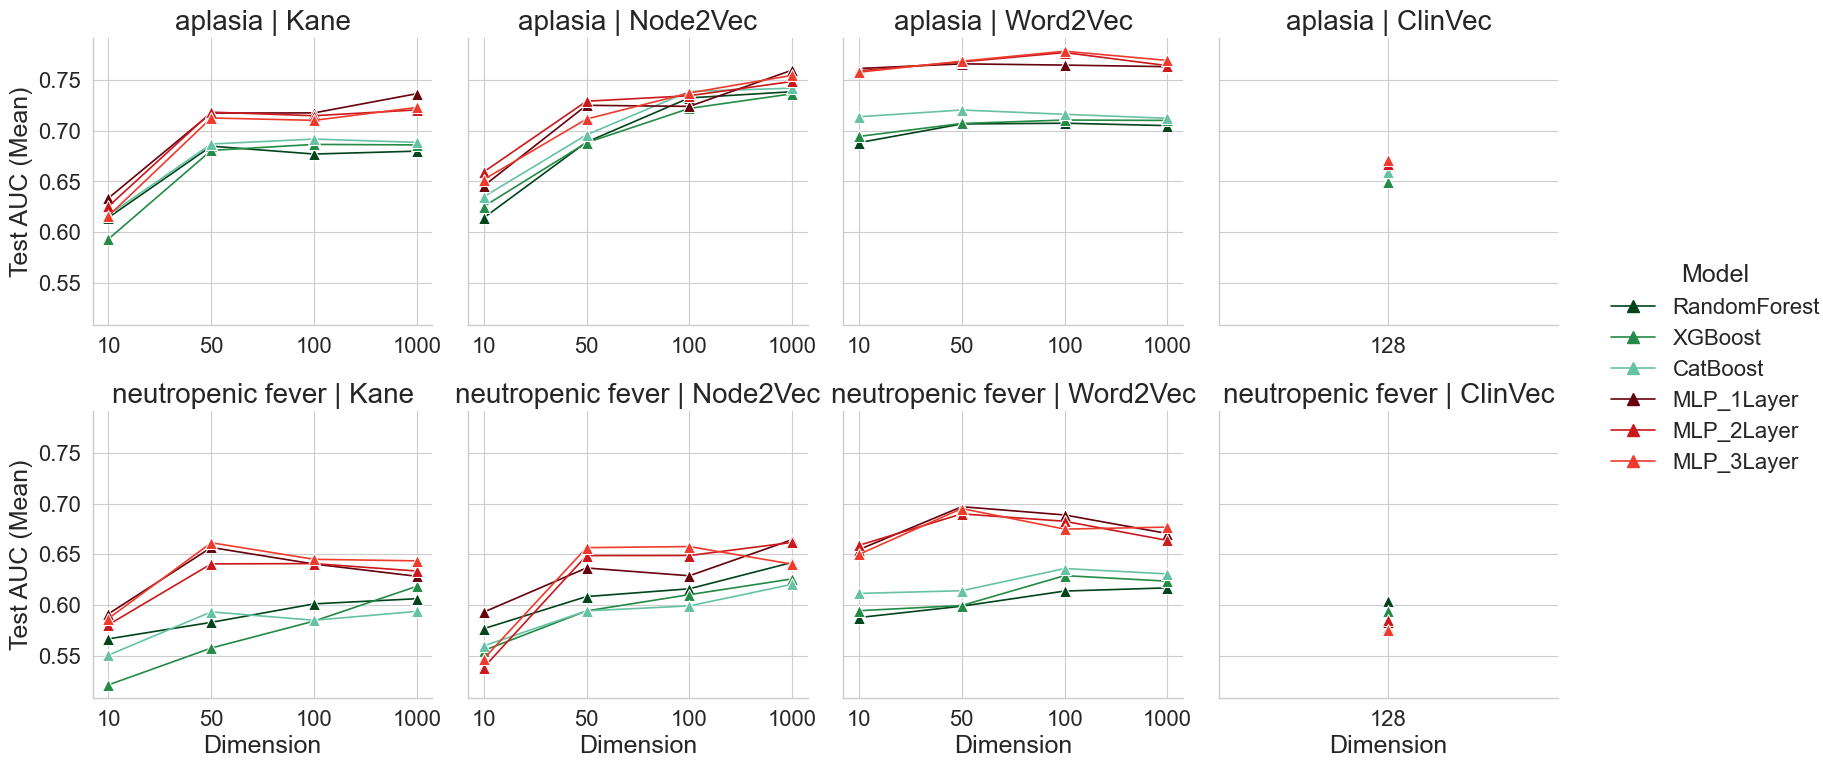

In [94]:
sub_df["Dimension_str"] = sub_df["Dimension"].astype(int).astype(str)

# Define a palette with shades
palette = {
    # Tree-based (greens)
    "RandomForest": "#00441B",  # very dark green
    "XGBoost": "#238B45",       # medium green
    "CatBoost": "#66C2A4",      # light green

    # MLP (reds)
    "MLP_1Layer": "#67000D",    # very dark red
    "MLP_2Layer": "#CB181D",    # medium red
    "MLP_3Layer": "#EF3B2C"     # light red
}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.8)

g = sns.relplot(
    data=sub_df,
    kind="line",
    x="Dimension_str",
    y="Test_AUC_Mean",
    hue="Model",
    #style="Model",
    col="Feature_Type",
    row="cohort_name",
    marker="^",
    markersize=8,
    palette=palette,
    height=3.8,
    aspect=1.4,
    facet_kws={'sharex': False}
)
fig = g.fig
fig.set_size_inches(16, 8)
g.set_axis_labels("Dimension", "Test AUC (Mean)", fontsize=18)
g.set_titles(row_template="{row_name}", col_template="{col_name}", size=20)
plt.setp(g._legend.get_title(), fontsize=18)
plt.setp(g._legend.get_texts(), fontsize=16)

g._legend.set_bbox_to_anchor((1.15, 0.5)) 
plt.tight_layout()
plt.savefig("figures/fig2.png", dpi=600, bbox_inches="tight")

In [95]:
# FIGURE 3 upto vs at adm

# selected dimensionality (similar to ClinVec) = 100

# selected number of layers (best overall performance) = 3


In [96]:
sub_df = concat_df[
    (concat_df["Model"].isin(['RandomForest', 'XGBoost', 'CatBoost', 'MLP_3Layer'])) &
    (
        ((concat_df["Feature_Type"].isin(["Kane", "Word2Vec", "Node2Vec"])) & (concat_df["Dimension"] == 100)) |    # embeddings
        ((concat_df["folder_name"].str.contains("OHE")) & (concat_df["Feature_Type"] == "Combined")) |             # one-hot
        (concat_df["Feature_Type"] == "ClinVec")   # ClinVec
    )
].sort_values(["cohort_name", "Feature_Type", "Model"])
sub_df["Feature_Type"] = sub_df["Feature_Type"].replace({"Combined":"One-Hot"})
sub_df["Model"] = sub_df["Model"].replace({"MLP_3Layer":"MLP"})


In [97]:
pivot_df = sub_df.pivot_table(
    index=["Model", "Feature_Type", "cohort_name"], 
    columns="adm_type",  
    values="Test_AUC_Mean"
).reset_index()

pivot_df["diff_upto_at"] = pivot_df["icd_codes_upto"] - pivot_df["icd_codes"]

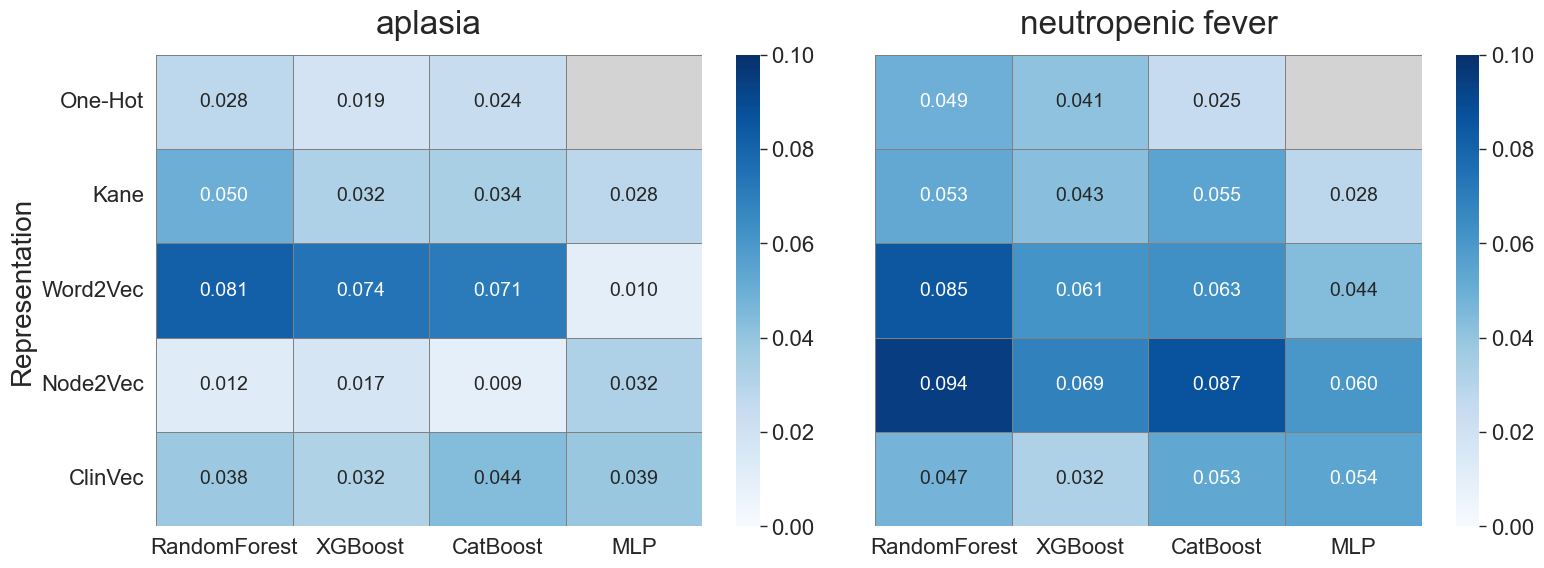

In [105]:
x_order = ['RandomForest', 'XGBoost', 'CatBoost', 'MLP']
y_order = ['One-Hot','Kane','Word2Vec','Node2Vec', 'ClinVec']

# Diverging palette: blue = positive
cmap = sns.color_palette("Blues", as_cmap=True)  # white → blue
cmap.set_bad(color='lightgray') 
# List of cohorts
cohorts = pivot_df["cohort_name"].unique()

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)



for i, cohort in enumerate(cohorts):
    # Filter cohort
    df_cohort = pivot_df[pivot_df["cohort_name"] == cohort]
    
    # Pivot for heatmap
    heat_data = df_cohort.pivot(index="Feature_Type", columns="Model", values="diff_upto_at")
    
    # Reindex rows and columns to fix order
    heat_data = heat_data.reindex(index=y_order, columns=x_order)
    
    res = sns.heatmap(
        heat_data, 
        annot=True, fmt=".3f", 
        cmap=cmap,
        linewidths=0.7, linecolor="gray",
        vmin=0, vmax=0.1,  # set colorbar range
        ax=axes[i],
        annot_kws={"size": 14}
    )
    cbar = res.collections[0].colorbar
    cbar.ax.tick_params(labelsize=16)

    axes[i].set_title(f"{cohort}",fontsize=24, pad=15)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Representation" if i == 0 else "", fontsize=20)  # only left plot y-axis
    axes[i].tick_params(axis='both', which='major', labelsize=16, rotation=0)

plt.tight_layout()
plt.savefig("figures/fig3.png", dpi=600)

In [106]:
# FIGURE 4

all_dfs = []

# Iterate over subfolders
for folder in EXP.iterdir():
    for subfolder in folder.iterdir():
        if subfolder.is_dir():
            csv_file = subfolder / "metrics.csv"
            
            if csv_file.exists():
                df = pd.read_csv(csv_file)
                
                # Add folder name as new column
                df["folder_name"] = subfolder.name
                df["adm_type"] = folder.name
                
                all_dfs.append(df)

# Concatenate all dataframes
if all_dfs:
    metrics_df = pd.concat(all_dfs, ignore_index=True)
else:
    metrics_df = pd.DataFrame()

metrics_df["cohort_name"] = np.where(metrics_df["folder_name"].str.contains("aplasia", case=False, na=False), "aplasia", "neutropenic fever")

metrics_df.loc[metrics_df["Feature_Type"].isna() & metrics_df["folder_name"].str.contains("node2vec"),"Feature_Type"] = "Node2Vec"
metrics_df.loc[metrics_df["Feature_Type"].isna() & metrics_df["folder_name"].str.contains("kane"),"Feature_Type"] = "Kane"

In [107]:
sub_df = metrics_df[
    (metrics_df["Model"].isin(['RandomForest', 'XGBoost', 'CatBoost', 'MLP_3Layer'])) &
    (
        ((metrics_df["Feature_Type"].isin(["Kane", "Word2Vec", "Node2Vec"])) & (metrics_df["Dimension"] == 100)) |    # embeddings
        ((metrics_df["folder_name"].str.contains("OHE")) & (metrics_df["Feature_Type"] == "Combined")) |               # one-hot
        (metrics_df["Feature_Type"] == "ClinVec")   # ClinVec
    )
].sort_values(["cohort_name", "Feature_Type", "Model"])
sub_df["Feature_Type"] = sub_df["Feature_Type"].replace({"Combined":"One-Hot"})
sub_df["Model"] = sub_df["Model"].replace({"MLP_3Layer":"MLP"})

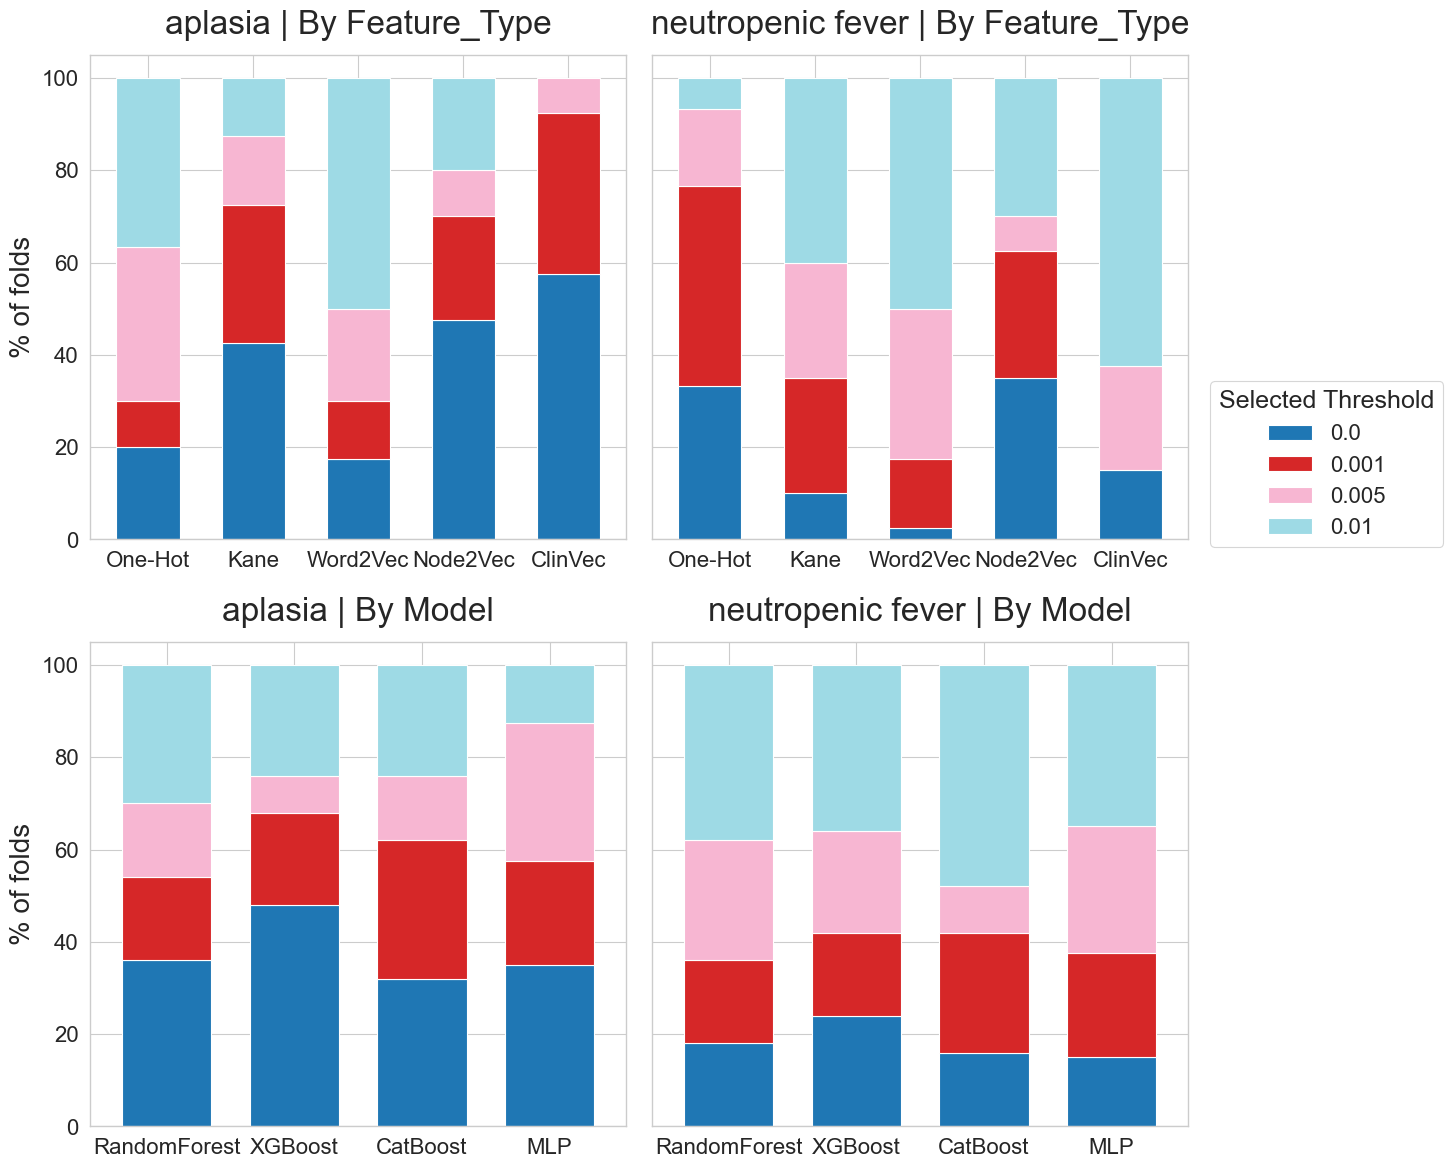

In [111]:
order1 = ['One-Hot','Kane','Word2Vec','Node2Vec', 'ClinVec']
order2 = ['RandomForest', 'XGBoost', 'CatBoost', 'MLP']

# Copy your dataframe
df = sub_df.copy()

# Unique cohorts
cohorts = df['Cohort'].unique()

# Set up 2x2 subplots
fig, axes = plt.subplots(2, len(cohorts), figsize=(15, 12), sharey=True)

# Ensure axes is always 2D array
if len(cohorts) == 1:
    axes = axes.reshape(2,1)

for j, cohort in enumerate(["aplasia","neutropenic fever"]):
    df_cohort = df[df['cohort_name'] == cohort]

    # Row 1: Feature_Type
    counts = df_cohort.groupby(['Feature_Type', 'Selected_Threshold']).size().reset_index(name='count')
    counts['pct'] = counts.groupby('Feature_Type')['count'].transform(lambda x: x / x.sum() * 100)
    pivot = counts.pivot(index='Feature_Type', columns='Selected_Threshold', values='pct').fillna(0)
    pivot = pivot.reindex(index=order1)
    pivot.plot(kind='bar', stacked=True, ax=axes[0,j], colormap='tab20', width=0.6, legend=False)
    
    axes[0,j].set_title(f"{cohort} | By Feature_Type", fontsize=24, pad=15)
    axes[0,j].set_xlabel("")
    axes[0,j].tick_params(axis='both', labelsize=16, rotation=0)
    axes[0,j].set_ylabel("% of folds" if j == 0 else "", fontsize=20)

    # Row 2: Model
    counts_model = df_cohort.groupby(['Model', 'Selected_Threshold']).size().reset_index(name='count')
    counts_model['pct'] = counts_model.groupby('Model')['count'].transform(lambda x: x / x.sum() * 100)
    pivot_model = counts_model.pivot(index='Model', columns='Selected_Threshold', values='pct').fillna(0)
    pivot_model = pivot_model.reindex(index=order2)
    pivot_model.plot(kind='bar', stacked=True, ax=axes[1,j], colormap='tab20', width=0.7, legend=False)
    
    axes[1,j].set_title(f"{cohort} | By Model", fontsize=24, pad=15)
    axes[1,j].set_xlabel("")
    axes[1,j].tick_params(axis='both', labelsize=16, rotation=0)
    axes[1,j].set_ylabel("% of folds" if j == 0 else "", fontsize=20)


# Place a single legend outside all plots
handles, labels = axes[1, -1].get_legend_handles_labels()
fig.legend(handles, labels, title="Selected Threshold", bbox_to_anchor=(0.81, 0.6), loc='center left', fontsize=16, title_fontsize=18, frameon=True)

plt.tight_layout(rect=[0, 0, 0.82, 1])  # leave space for legend
plt.savefig("figures/fig4.png", dpi=600)


In [120]:
# Aggregate counts by Cohort and Feature Type
for cohort in ["aplasia", "neutropenic fever"]:
    print(f"\n{'='*60}")
    print(f"COHORT: {cohort.upper()} ANALYSIS")
    print(f"{'='*60}")
    
    df_cohort = df[df['cohort_name'] == cohort]
    
    # Distribution by Feature Type
    print("\n[1] Selected Thresholds by Feature Type (%)")
    counts_feat = df_cohort.groupby(['Feature_Type', 'Selected_Threshold']).size().reset_index(name='count')
    counts_feat['pct'] = counts_feat.groupby('Feature_Type')['count'].transform(lambda x: x / x.sum() * 100)
    pivot_feat = counts_feat.pivot(index='Feature_Type', columns='Selected_Threshold', values='pct').fillna(0)
    print(pivot_feat.round(2))
    
    # Distribution by Model Type
    print("\n[2] Selected Thresholds by Model Type (%)")
    counts_model = df_cohort.groupby(['Model', 'Selected_Threshold']).size().reset_index(name='count')
    counts_model['pct'] = counts_model.groupby('Model')['count'].transform(lambda x: x / x.sum() * 100)
    pivot_model = counts_model.pivot(index='Model', columns='Selected_Threshold', values='pct').fillna(0)
    print(pivot_model.round(2))
    print(f"\nTotal folds analyzed for {cohort}: {len(df_cohort)}")


COHORT: APLASIA ANALYSIS

[1] Selected Thresholds by Feature Type (%)
Selected_Threshold  0.000  0.001  0.005  0.010
Feature_Type                                  
ClinVec              57.5   35.0   7.50   0.00
Kane                 42.5   30.0  15.00  12.50
Node2Vec             47.5   22.5  10.00  20.00
One-Hot              20.0   10.0  33.33  36.67
Word2Vec             17.5   12.5  20.00  50.00

[2] Selected Thresholds by Model Type (%)
Selected_Threshold  0.000  0.001  0.005  0.010
Model                                         
CatBoost             32.0   30.0   14.0   24.0
MLP                  35.0   22.5   30.0   12.5
RandomForest         36.0   18.0   16.0   30.0
XGBoost              48.0   20.0    8.0   24.0

Total folds analyzed for aplasia: 190

COHORT: NEUTROPENIC FEVER ANALYSIS

[1] Selected Thresholds by Feature Type (%)
Selected_Threshold  0.000  0.001  0.005  0.010
Feature_Type                                  
ClinVec             15.00   0.00  22.50  62.50
Kane          

In [121]:
# FIGURE 5

# Filter to best admission type (ICD Codes)
metrics_df = concat_df.copy()

# Helper: Define Strategies
def get_strategy(row):
    folder = str(row.get("folder_name", ""))
    ftype = str(row.get("Feature_Type", ""))
    if "OHE" in folder: return "One-Hot"
    elif ftype in ["Kane", "Word2Vec", "Node2Vec", "ClinVec"]: return ftype
    return "Other"

# Define Config Labels
def get_config_label(row):
    model_name = str(row["Model"]).replace("Layer", "L") 
    if row["Strategy"] == "One-Hot": return f"{model_name}\n({row['Feature_Type']})"
    elif row["Strategy"] == "ClinVec": return f"{model_name}\n(128d)"
    else:
        dim = int(row["Dimension"]) if pd.notna(row["Dimension"]) else ""
        return f"{model_name}\n({dim}d)"

# Apply helpers to create standard columns
metrics_df["Strategy"] = metrics_df.apply(get_strategy, axis=1)
metrics_df = metrics_df[metrics_df["Strategy"] != "Other"].copy()
metrics_df["Config_Label"] = metrics_df.apply(get_config_label, axis=1)

# Extract best results

best_idx = metrics_df.groupby(["cohort_name", "Strategy"])["Test_AUC_Mean"].idxmax()
best_config_df = metrics_df.loc[best_idx].copy()

# Enforce logical order for plotting
strategy_order = ["One-Hot", "Kane", "Word2Vec", "Node2Vec", "ClinVec"]
best_config_df["Strategy"] = pd.Categorical(best_config_df["Strategy"], categories=strategy_order, ordered=True)
best_config_df = best_config_df.sort_values(["cohort_name", "Strategy"])

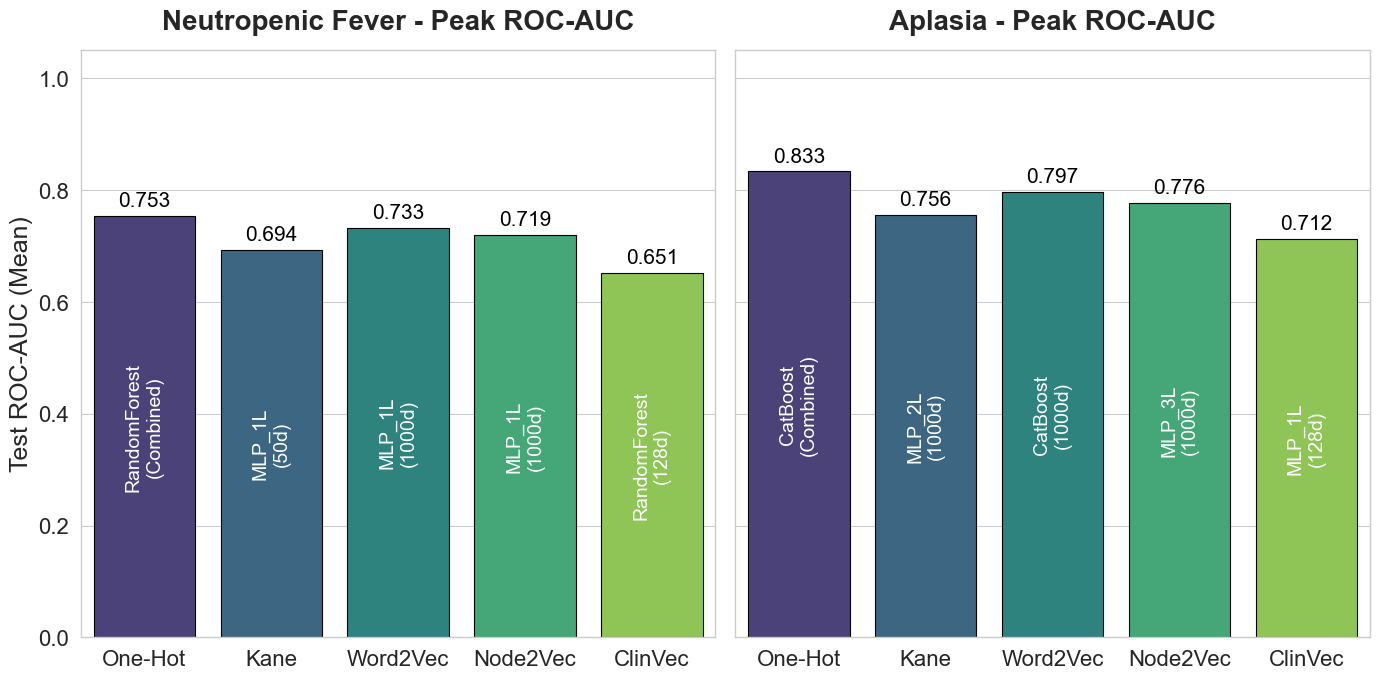

In [122]:
# ROC-AUC bar plot.

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
sns.set_style("whitegrid")

cohorts = ["neutropenic fever", "aplasia"]

for i, cohort in enumerate(cohorts):
    ax = axes[i]
    cohort_data = best_config_df[best_config_df["cohort_name"] == cohort]
    
    # Plot the bars
    sns.barplot(
        data=cohort_data, 
        x="Strategy", 
        y="Test_AUC_Mean",
        hue="Strategy", 
        ax=ax,
        palette="viridis",
        edgecolor="black",
        legend=False
    )
    
    # Add Text Annotations 
    for j, p in enumerate(ax.patches):
        height = p.get_height()
        config_label = cohort_data.iloc[j]["Config_Label"]
        
        # Writes Config (e.g., XGBoost 100d) inside the middle of the bar
        ax.text(
            p.get_x() + p.get_width() / 2., 
            height / 2.,  
            config_label, 
            ha="center", va="center", 
            color="white", fontsize=14,
            rotation=90
        )
        
        # Writes exact AUC score right above the top of the bar
        ax.text(
            p.get_x() + p.get_width() / 2., 
            height + 0.01, 
            f"{height:.3f}", 
            ha="center", va="bottom", 
            color="black", fontsize=15
        )

    ax.set_title(f"{cohort.title()} - Peak ROC-AUC", fontsize=20, fontweight="bold", pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("Test ROC-AUC (Mean)" if i == 0 else "", fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_ylim(0, 1.05) 

plt.tight_layout()
plt.savefig("figures/fig5.png", dpi=600, bbox_inches="tight")

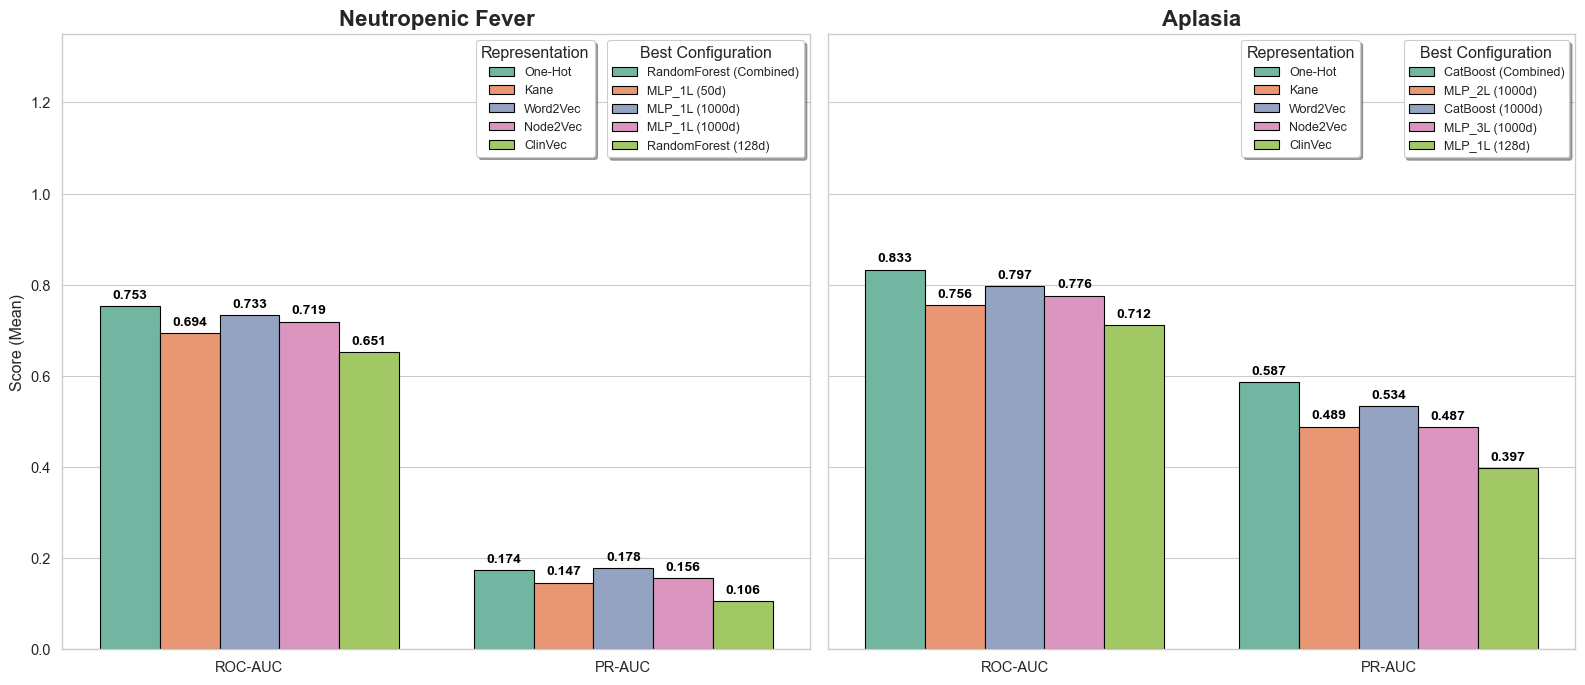

In [23]:
# ROC-AUC + PR-AUC

# Prepare Data
combined_df = best_config_df.melt(
    id_vars=["cohort_name", "Strategy", "Config_Label"], 
    value_vars=["Test_AUC_Mean", "Test_AUPRC_Mean"], 
    var_name="Metric", 
    value_name="Score"
)
combined_df["Metric"] = combined_df["Metric"].replace({"Test_AUC_Mean": "ROC-AUC", "Test_AUPRC_Mean": "PR-AUC"})

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
sns.set_style("whitegrid")

cohorts = ["neutropenic fever", "aplasia"]
strategy_order = ["One-Hot", "Kane", "Word2Vec", "Node2Vec", "ClinVec"]
strategy_palette = sns.color_palette("Set2", n_colors=5)

for i, cohort in enumerate(cohorts):
    ax = axes[i]
    cohort_data = combined_df[combined_df["cohort_name"] == cohort]    
    # Plot the bars
    sns.barplot(
        data=cohort_data, 
        x="Metric", 
        y="Score", 
        hue="Strategy",
        hue_order=strategy_order,
        ax=ax,
        palette=strategy_palette,
        edgecolor="black"
    )    
    # Add Value Labels above bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2., 
                height + 0.01, 
                f"{height:.3f}", 
                ha="center", va="bottom", 
                color="black", fontsize=10, fontweight="bold"
            )
    # Legends
    handles, labels = ax.get_legend_handles_labels()
    
    # Legend 1: Strategy
    leg1 = ax.legend(handles, labels, title="Representation", loc="upper right", 
                     bbox_to_anchor=(0.72, 1.0), frameon=True, fancybox=True, shadow=True, fontsize=9)
    ax.add_artist(leg1)
    
    # Legend 2: Best Config
    winner_labels = [
        best_config_df[(best_config_df["cohort_name"]==cohort) & (best_config_df["Strategy"]==s)].iloc[0]["Config_Label"].replace("\n", " ")
        for s in strategy_order
    ]
    ax.legend(handles, winner_labels, title="Best Configuration", loc="upper right", 
              bbox_to_anchor=(1.0, 1.0), frameon=True, fancybox=True, shadow=True, fontsize=9)

    ax.set_title(f"{cohort.title()}", fontsize=16, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Score (Mean)" if i == 0 else "")
    ax.set_ylim(0, 1.35) 

plt.tight_layout()
plt.savefig("figures/fig6.png", dpi=400, bbox_inches="tight")